In [33]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [10]:
df=pd.read_excel("C:/Users/aadhi/OneDrive/Desktop/Elevate_labs/Tourist_individual.xlsx")

In [12]:
df

,district_id,District_name,District_Region,Attraction_id,Attraction_name,Location,Type,Description,Visiting_year,Domestic_visitors,International_visitors,Total_visitors,Rating_avg,Number_of_Reviews
0,3,Hyderabad,Capital Region,1,Charminar,Hyderabad,Historical,Iconic monument in the heart of Hyderabad.,2024,1200000,80000,1280000,4.8,9500
1,3,Hyderabad,Capital Region,2,Golconda Fort,Hyderabad,Historical,Famous for its acoustics and structure.,2024,950000,50000,1000000,4.6,8800
2,3,Hyderabad,Capital Region,3,Ramoji Film City,Hyderabad,Entertainment,One of the world’s largest film cities.,2024,1100000,90000,1190000,4.7,9100
3,3,Hyderabad,Capital Region,4,Hussain Sagar Lake,Hyderabad,Natural,Famous lake with a Buddha statue.,2024,850000,30000,880000,4.5,7800
4,3,Hyderabad,Capital Region,5,KBR Park,Hyderabad,Natural,Urban forest and jogging park.,2024,600000,20000,620000,4.4,6700
5,31,Warangal,Eastern Telangana,6,Warangal Fort,Warangal,Historical,Kakatiya dynasty fort with sculptures.,2024,450000,15000,465000,4.3,5900
6,17,Mulugu,Eastern Telangana,7,Ramappa Temple,Mulugu,Historical,UNESCO heritage site.,2024,500000,12000,512000,4.7,6200
7,17,Mulugu,Eastern Telangana,8,Laknavaram Lake,Mulugu,Natural,Scenic lake with hanging bridge.,2024,300000,8000,308000,4.2,5100
8,9,Karimnagar,Northern Telangana,9,Elgandal Fort,Karimnagar,Historical,Historic fort on hillock.,2024,220000,5000,225000,4.1,4600
9,9,Karimnagar,Northern Telangana,10,Lower Manair Dam,Karimnagar,Natural,Dam with garden and boating.,2024,270000,7000,277000,4.3,4900


In [14]:
df.isnull().sum()

district_id               0
District_name             0
District_Region           0
Attraction_id             0
Attraction_name           0
Location                  0
Type                      0
Description               0
Visiting_year             0
Domestic_visitors         0
International_visitors    0
Total_visitors            0
Rating_avg                0
Number_of_Reviews         0
dtype: int64

In [18]:
df.duplicated().sum()

0

In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 14 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   district_id             50 non-null     int64  
 1   District_name           50 non-null     object 
 2   District_Region         50 non-null     object 
 3   Attraction_id           50 non-null     int64  
 4   Attraction_name         50 non-null     object 
 5   Location                50 non-null     object 
 6   Type                    50 non-null     object 
 7   Description             50 non-null     object 
 8   Visiting_year           50 non-null     int64  
 9   Domestic_visitors       50 non-null     int64  
 10  International_visitors  50 non-null     int64  
 11  Total_visitors          50 non-null     int64  
 12  Rating_avg              50 non-null     float64
 13  Number_of_Reviews       50 non-null     int64  
dtypes: float64(1), int64(7), object(6)
memory us

In [24]:
df.dtypes

district_id                 int64
District_name              object
District_Region            object
Attraction_id               int64
Attraction_name            object
Location                   object
Type                       object
Description                object
Visiting_year               int64
Domestic_visitors           int64
International_visitors      int64
Total_visitors              int64
Rating_avg                float64
Number_of_Reviews           int64
dtype: object

In [26]:
df.describe()

,district_id,Attraction_id,Visiting_year,Domestic_visitors,International_visitors,Total_visitors,Rating_avg,Number_of_Reviews
count,50.000000,50.00000,50.0,5.000000e+01,50.000000,5.000000e+01,50.000000,50.00000
mean,15.700000,25.50000,2024.0,3.778000e+05,10790.000000,3.885900e+05,4.328000,5246.00000
std,10.256407,14.57738,0.0,2.304879e+05,17297.295412,2.462810e+05,0.228607,1653.59349
min,1.000000,1.00000,2024.0,1.500000e+05,1500.000000,1.520000e+05,4.000000,2800.00000
25%,7.000000,13.25000,2024.0,2.425000e+05,3000.000000,2.462500e+05,4.100000,3925.00000
50%,15.500000,25.50000,2024.0,3.000000e+05,5250.000000,3.080000e+05,4.300000,5050.00000
75%,23.750000,37.75000,2024.0,4.175000e+05,9875.000000,4.231250e+05,4.500000,6075.00000
max,33.000000,50.00000,2024.0,1.200000e+06,90000.000000,1.280000e+06,4.800000,9500.00000


# Univariate Analysis

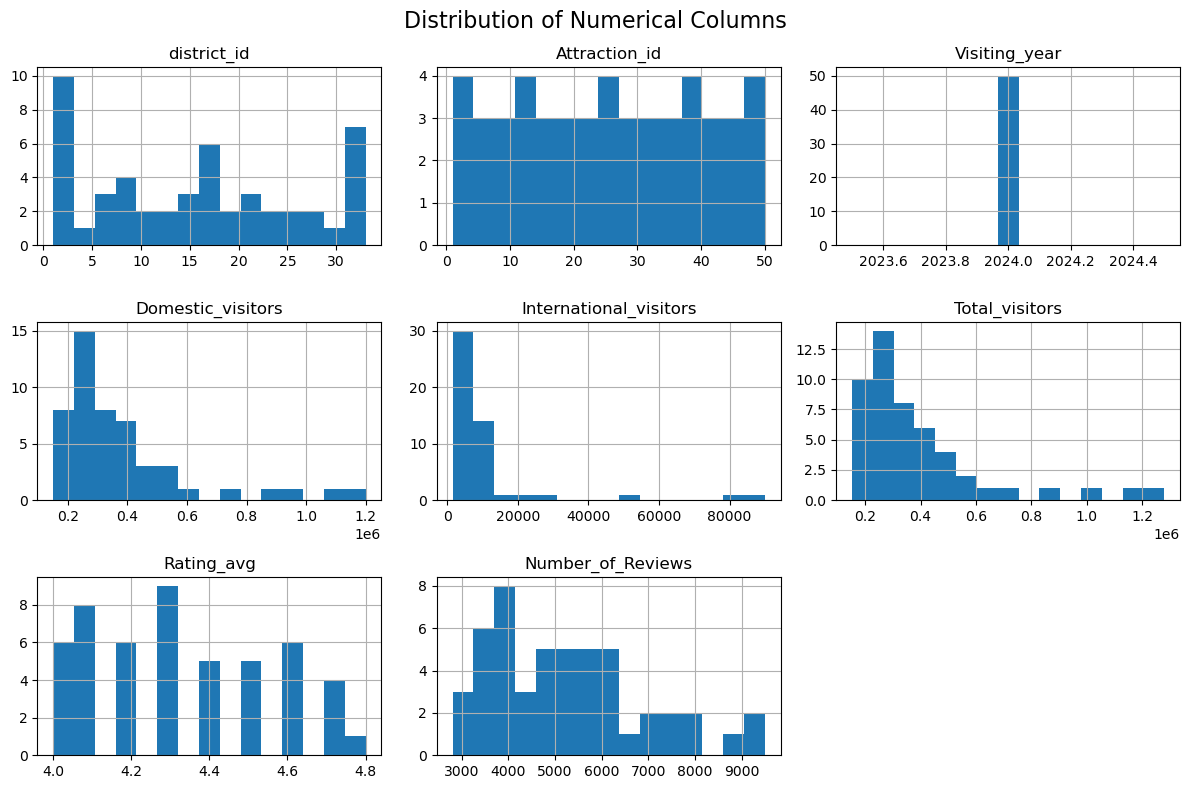

In [35]:
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns
df[numerical_cols].hist(figsize=(12, 8), bins=15)
plt.suptitle("Distribution of Numerical Columns", fontsize=16)
plt.tight_layout()
plt.show()

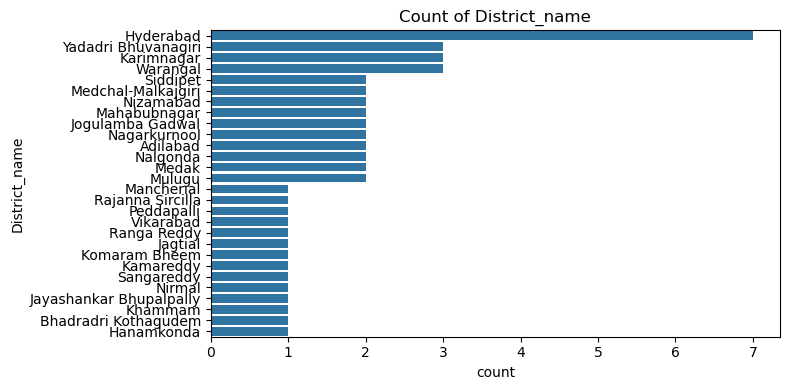

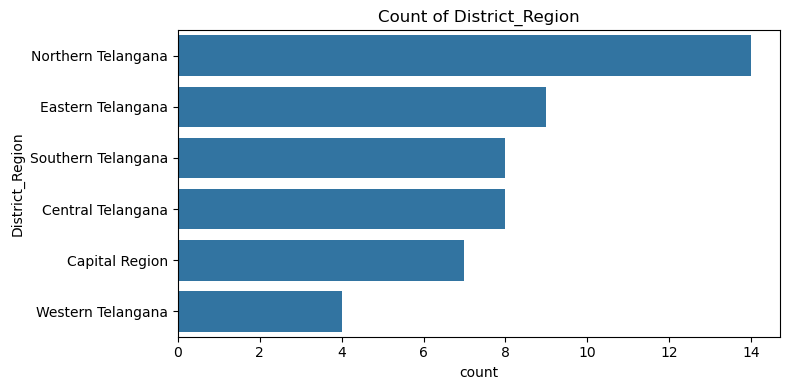

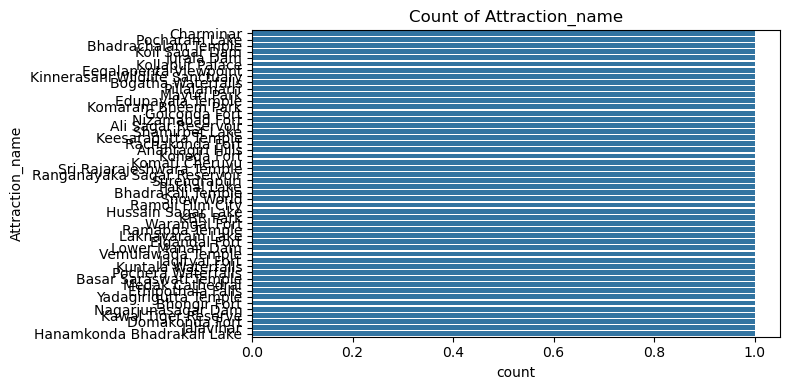

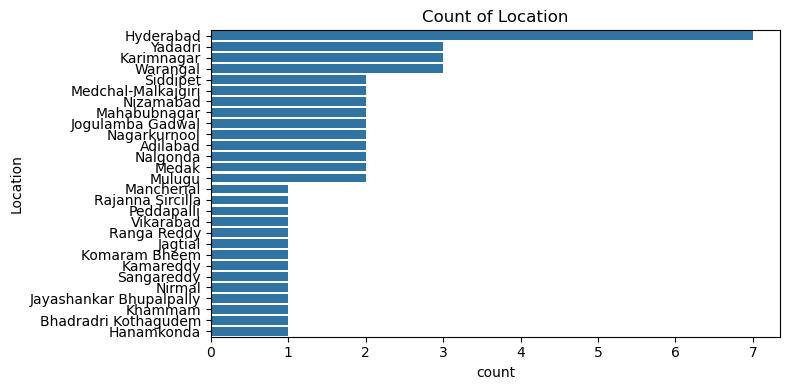

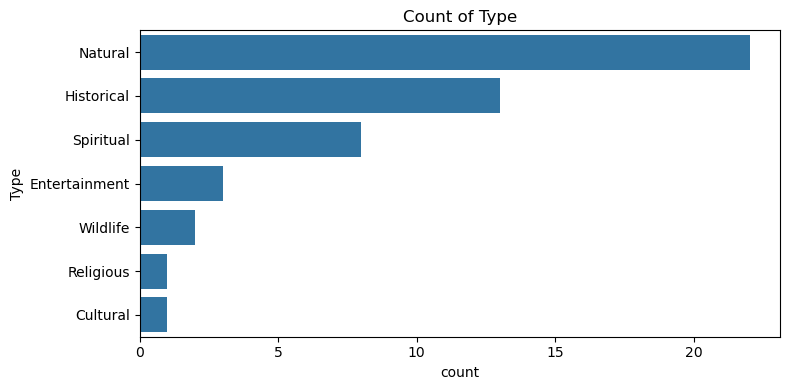

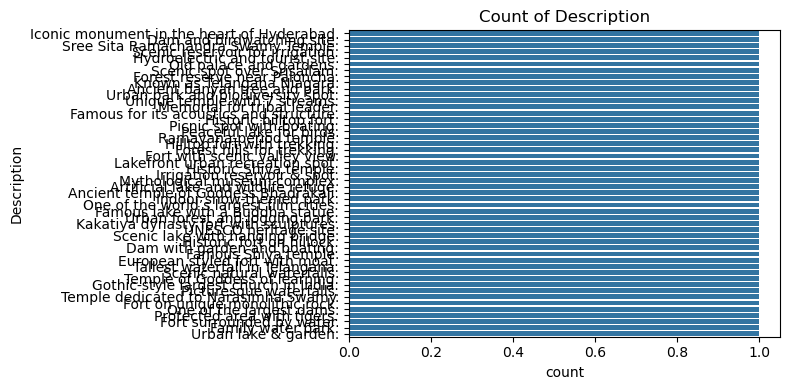

In [37]:
categorical_cols = df.select_dtypes(include=['object']).columns
for col in categorical_cols:
    plt.figure(figsize=(8, 4))
    sns.countplot(y=col, data=df, order=df[col].value_counts().index)
    plt.title(f'Count of {col}')
    plt.tight_layout()
    plt.show()

# Bivariate Analysis

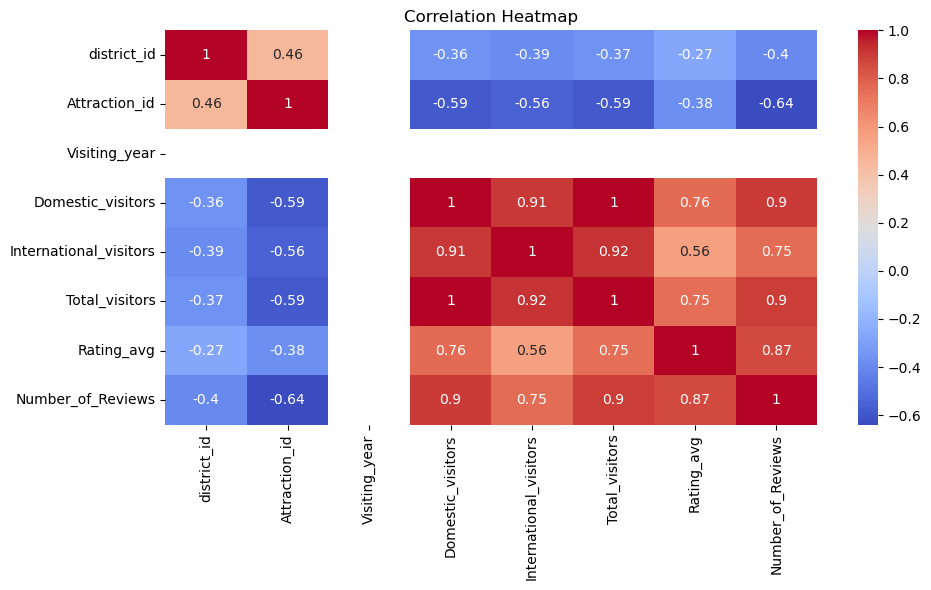

In [42]:
plt.figure(figsize=(10, 6))
sns.heatmap(df[numerical_cols].corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

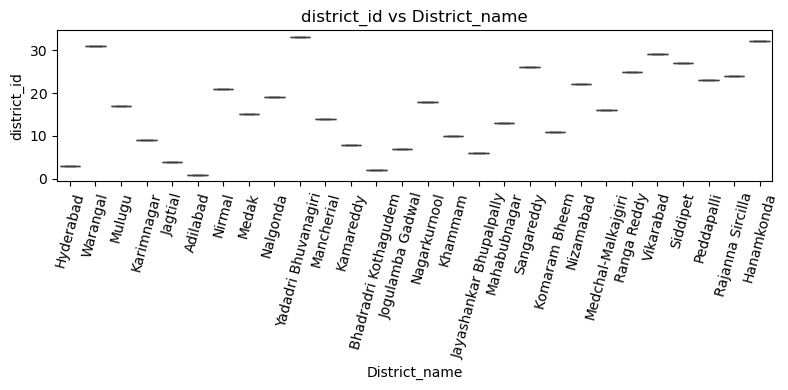

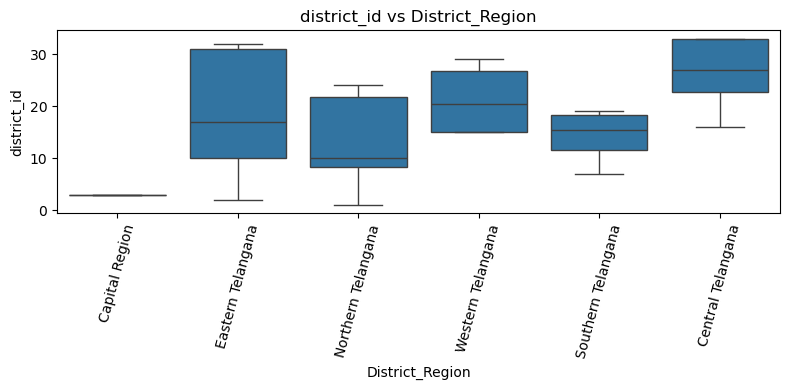

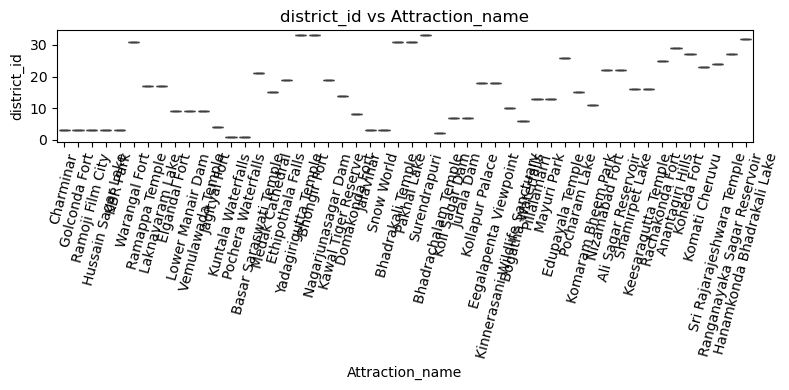

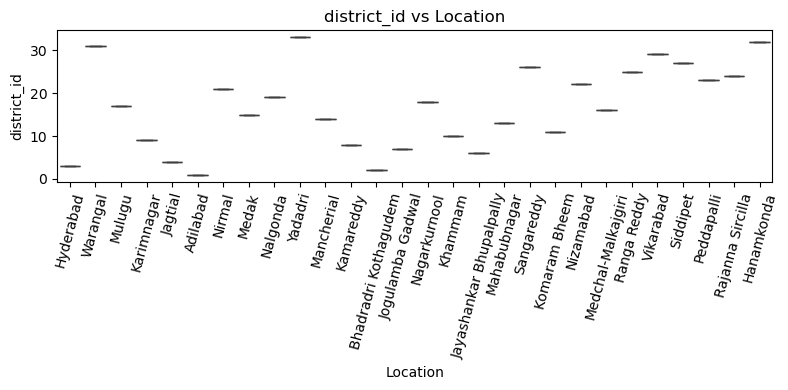

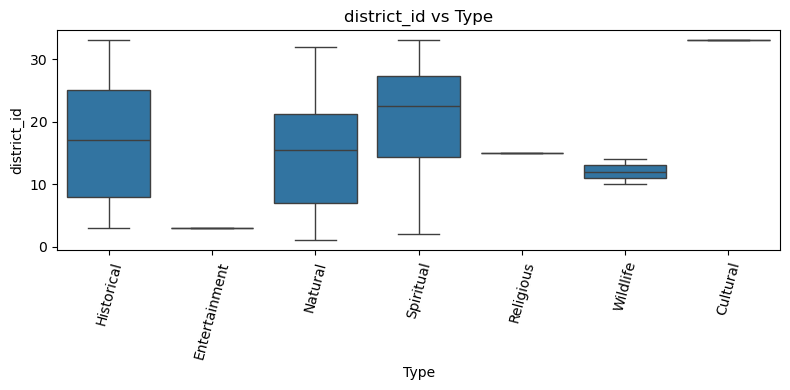

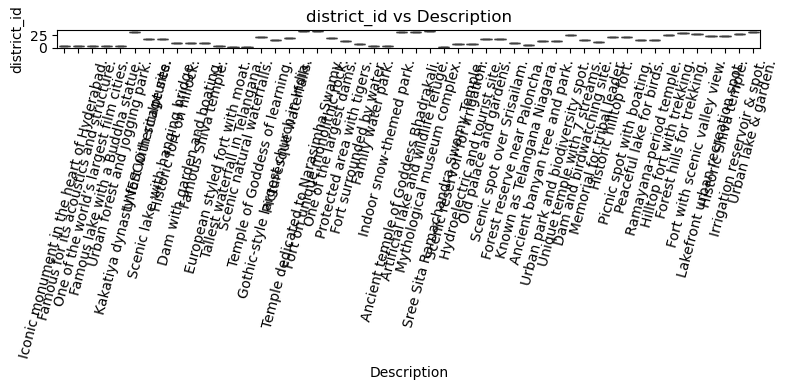

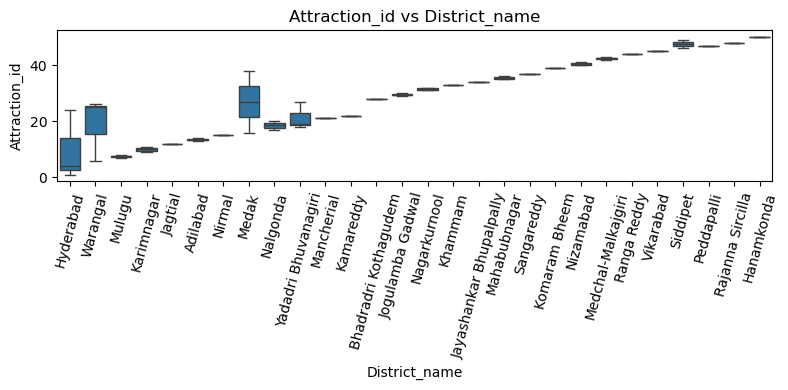

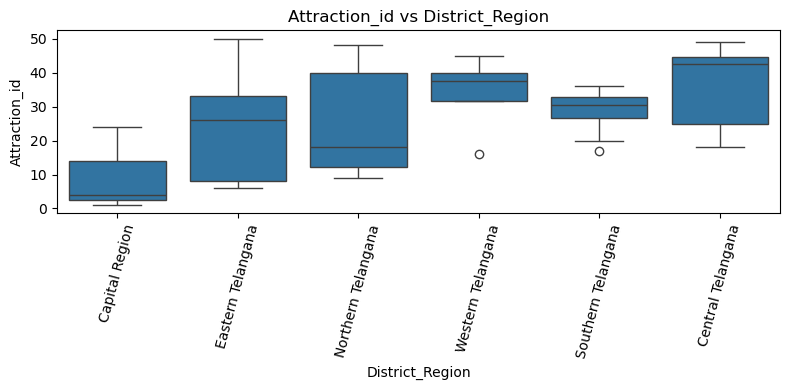

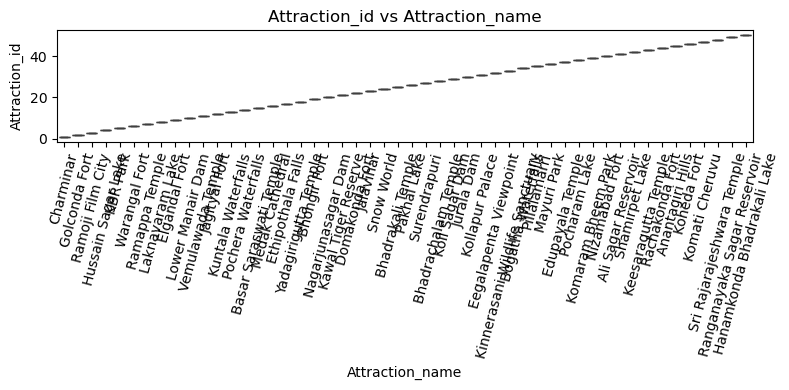

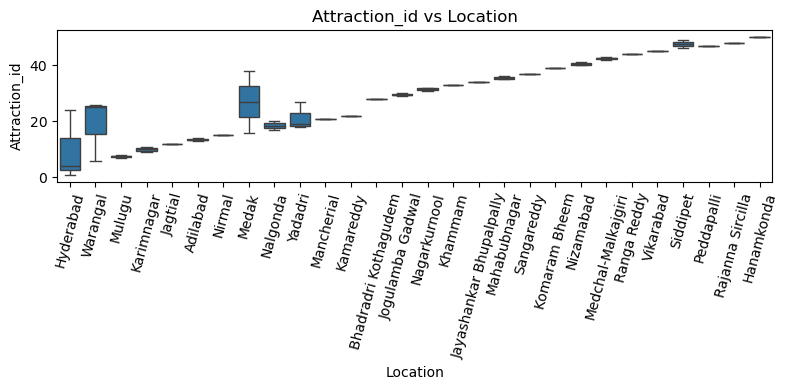

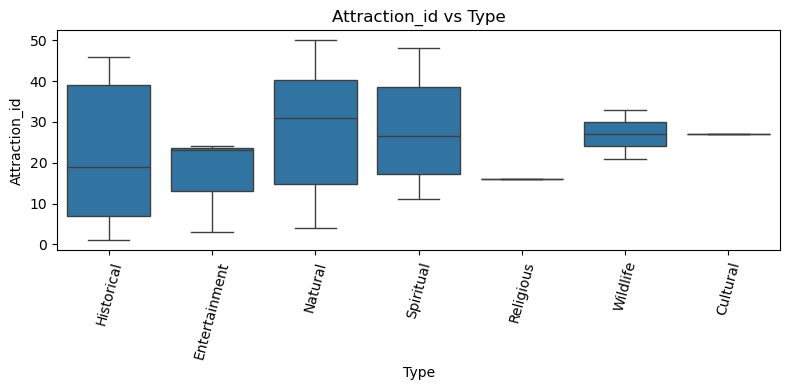

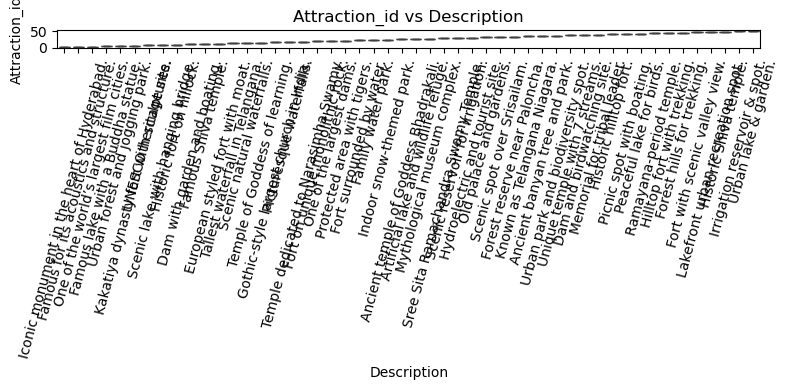

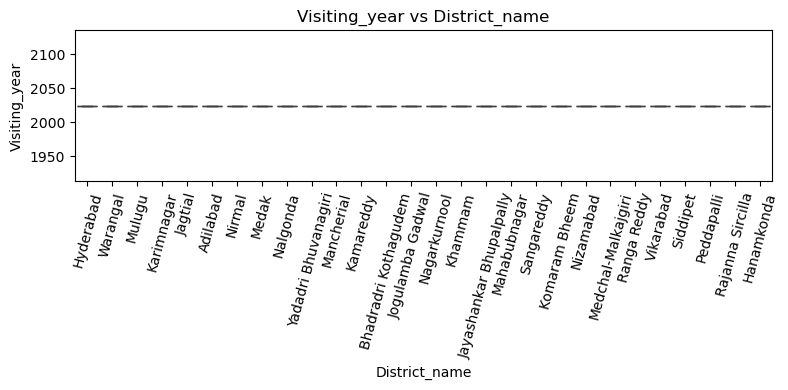

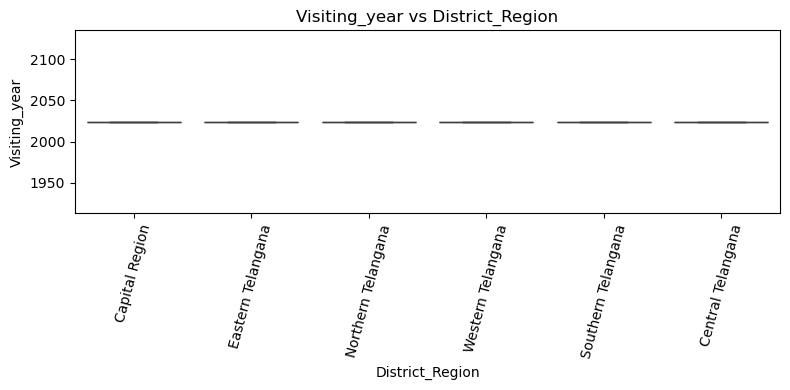

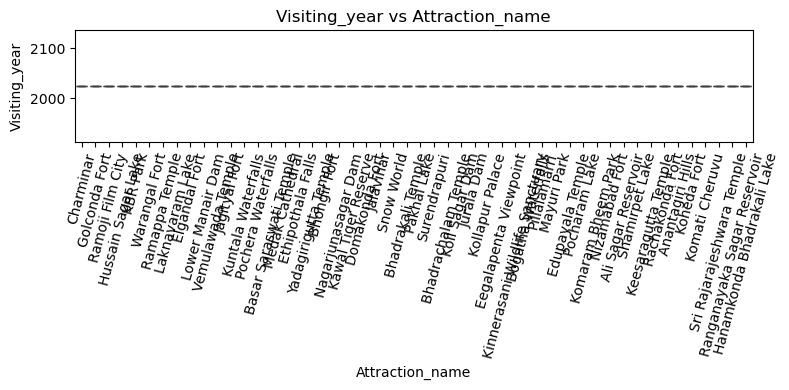

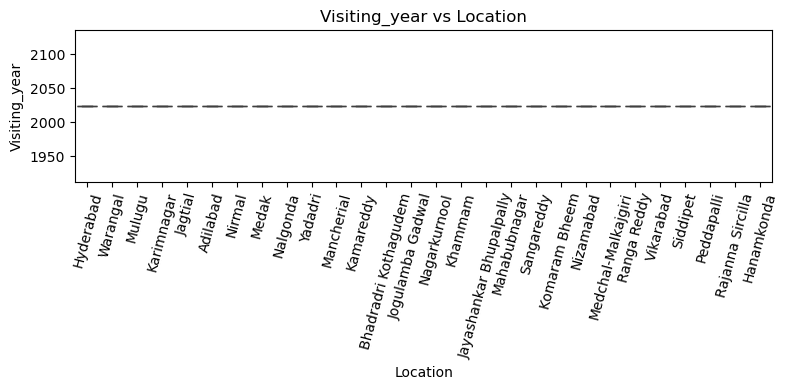

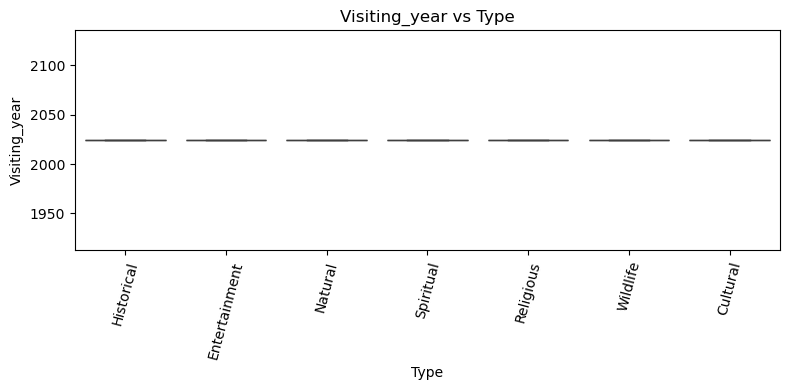

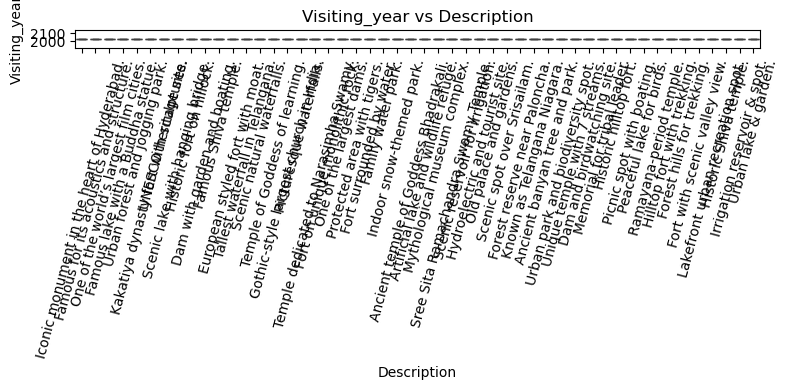

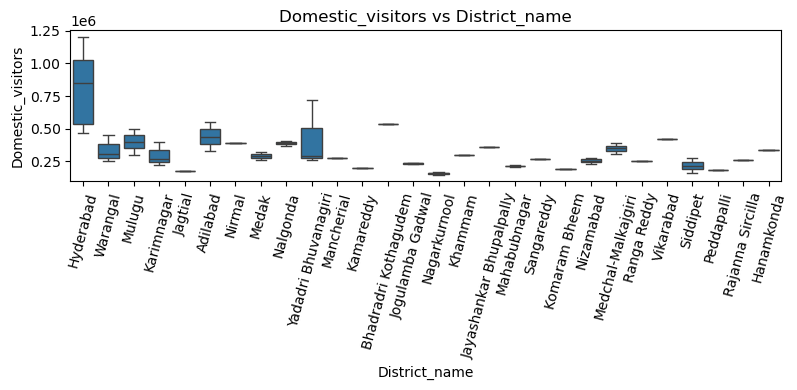

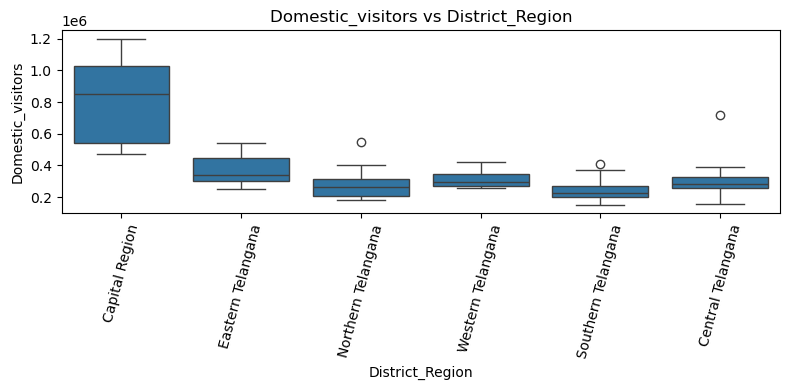

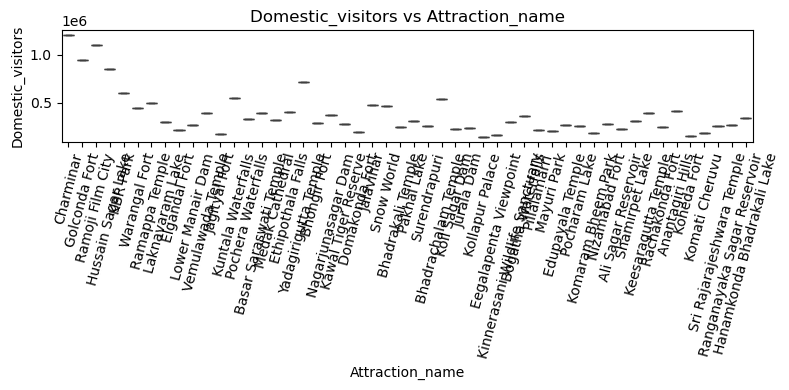

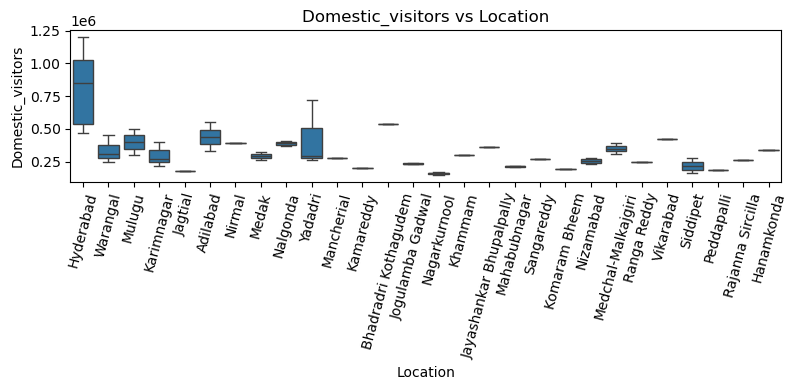

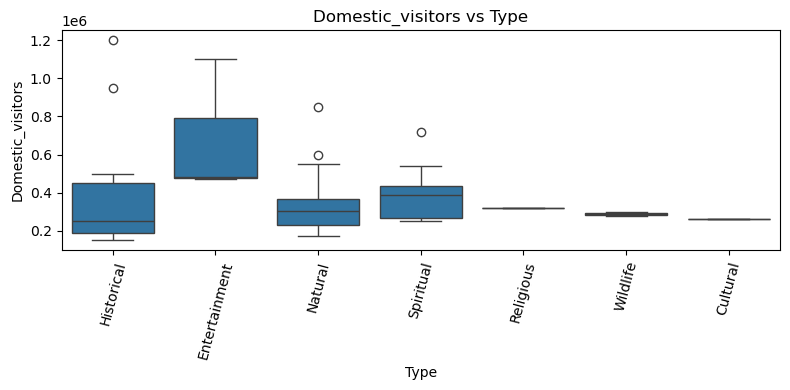

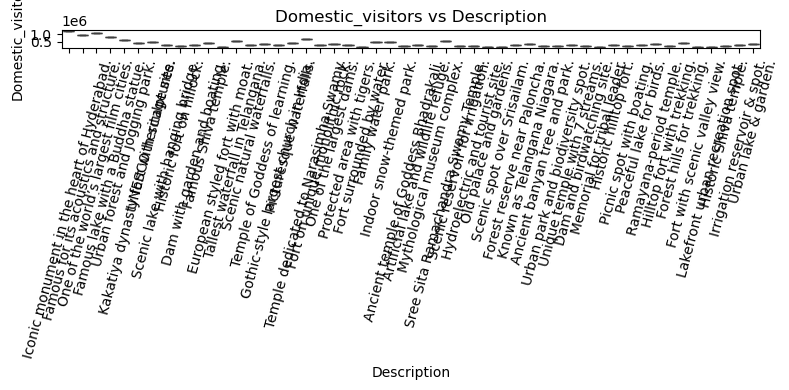

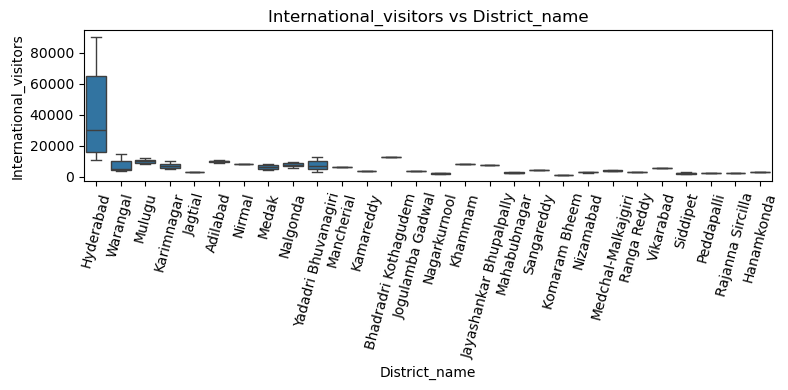

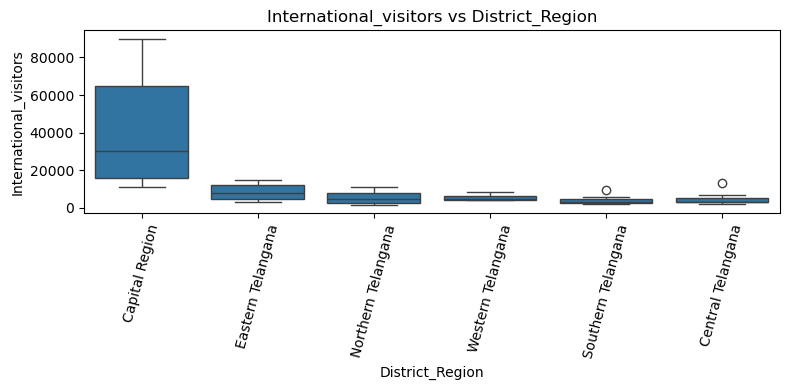

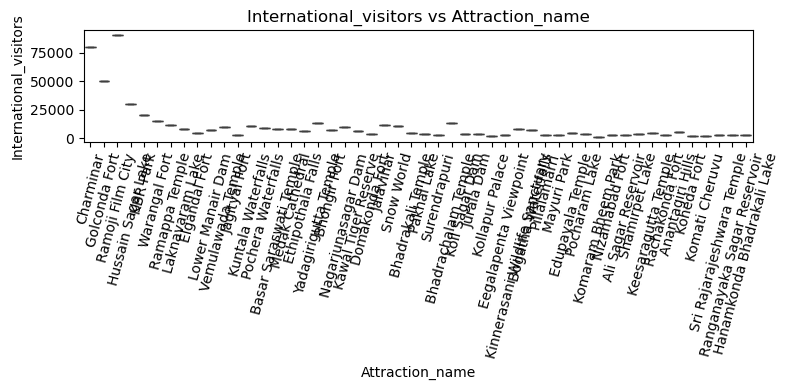

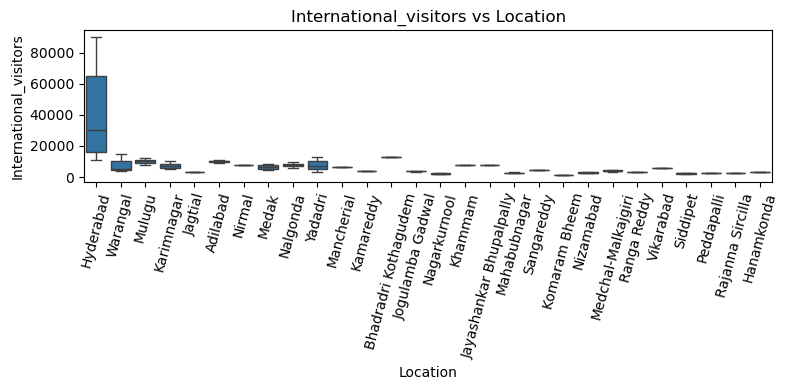

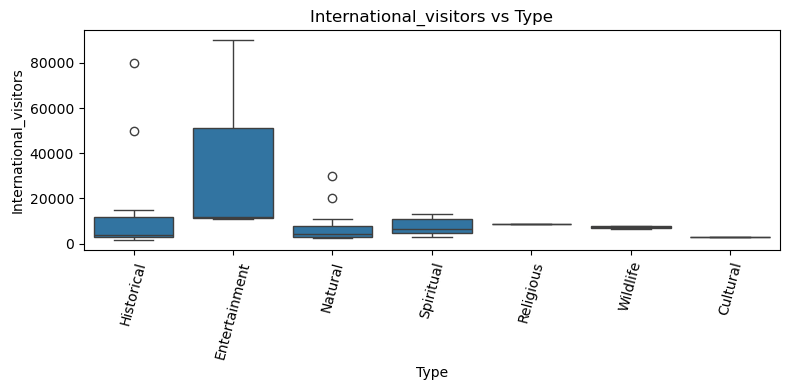

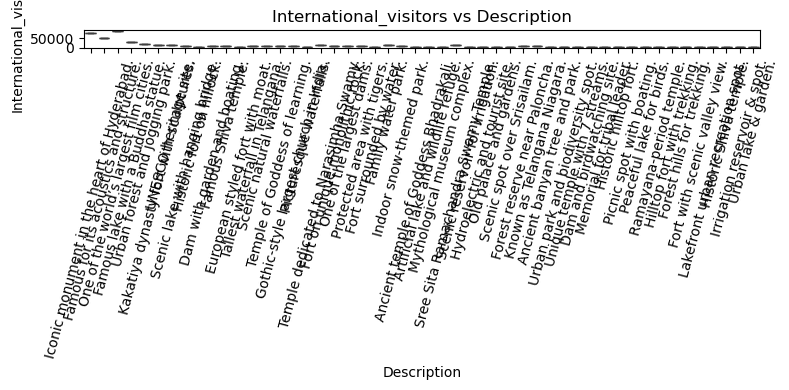

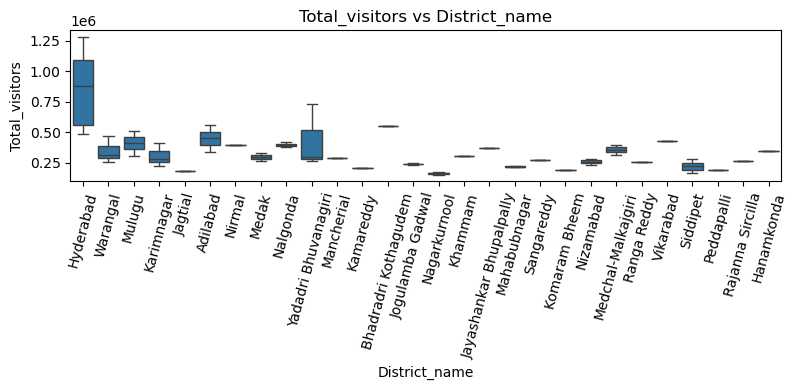

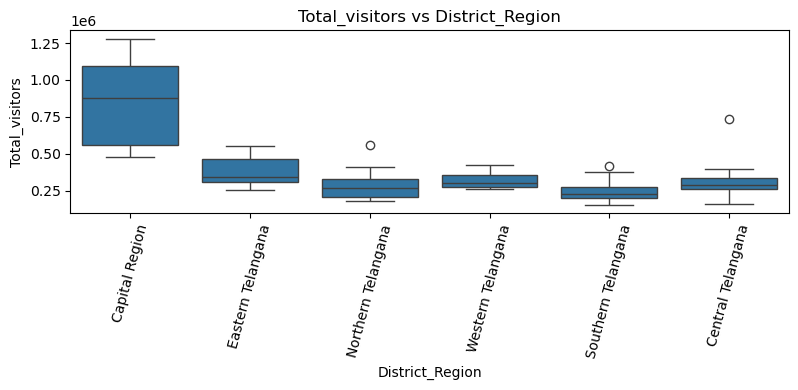

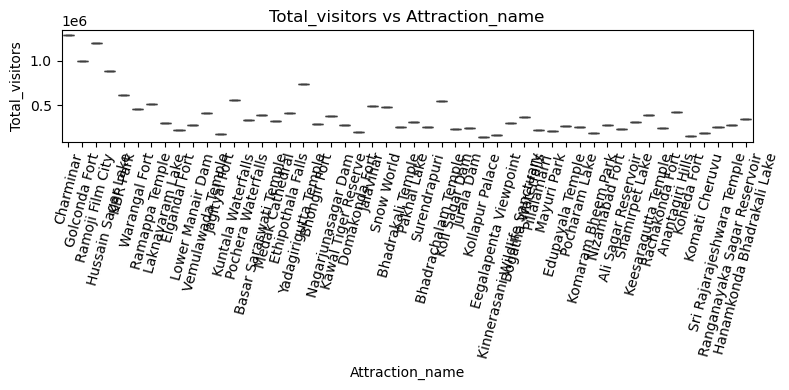

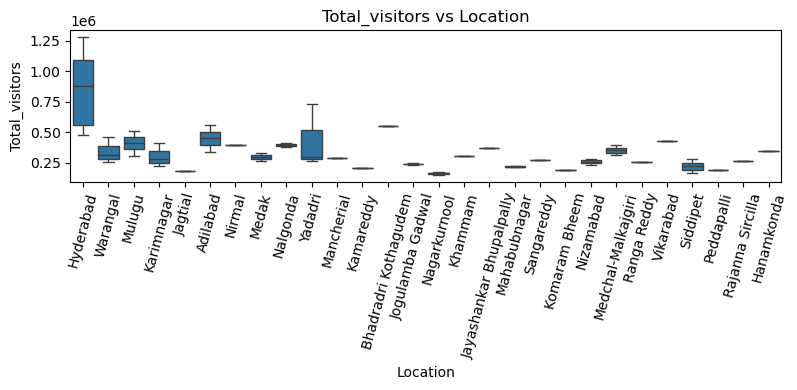

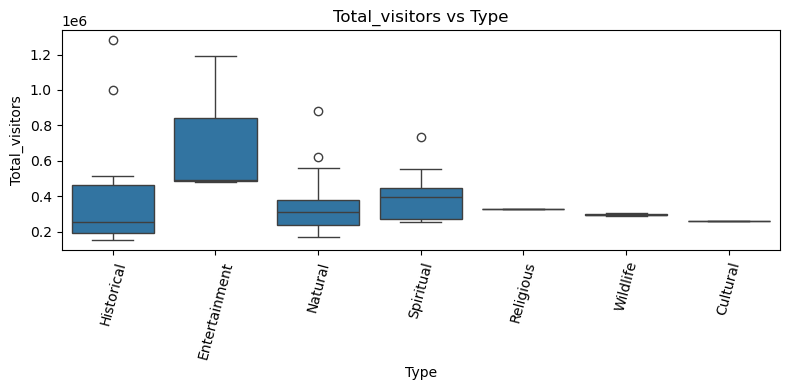

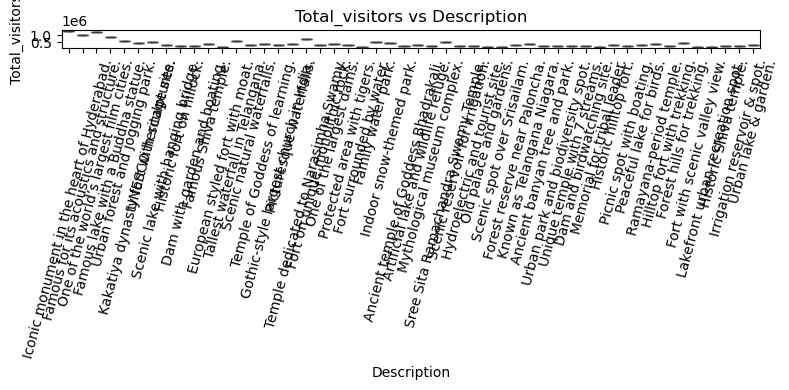

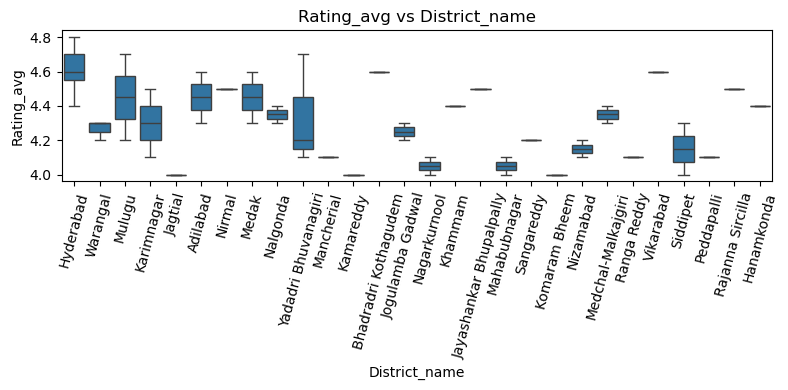

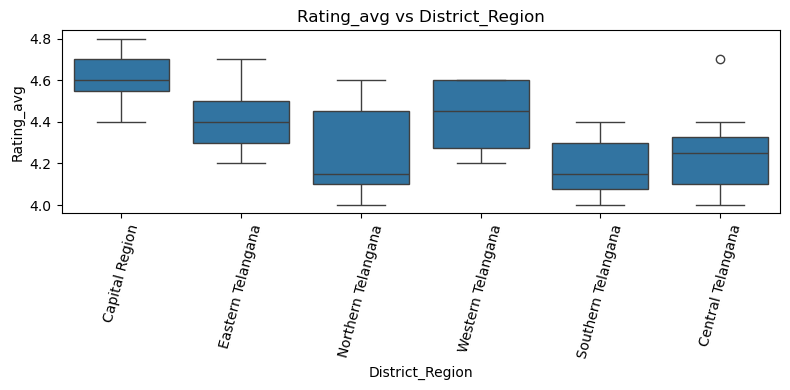

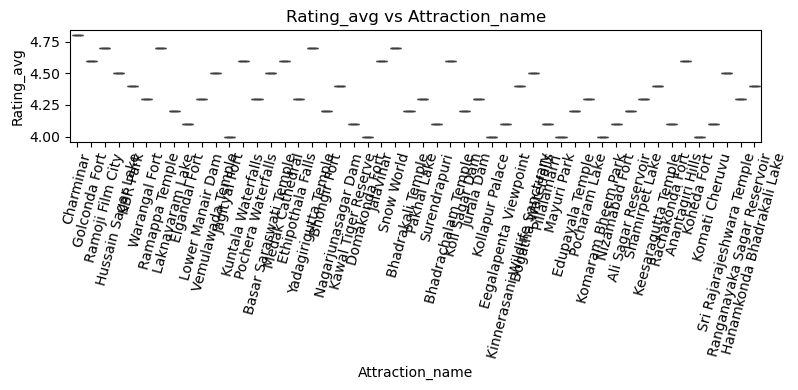

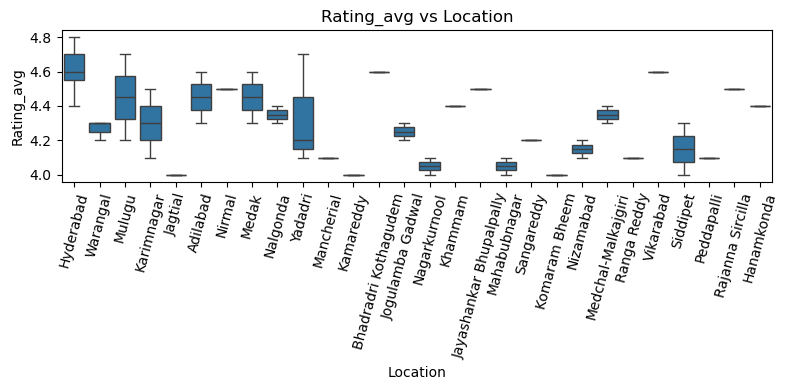

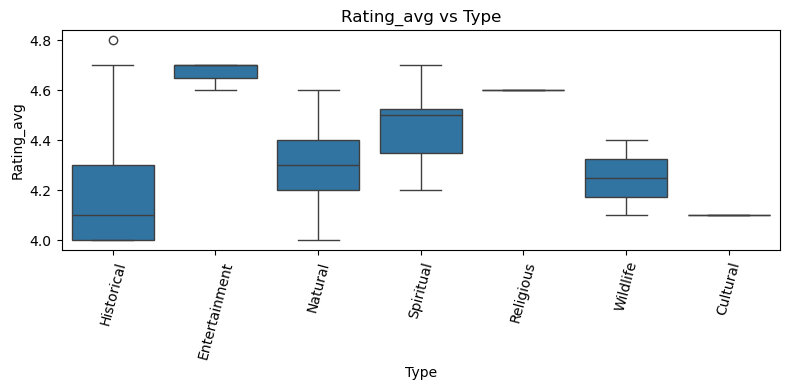

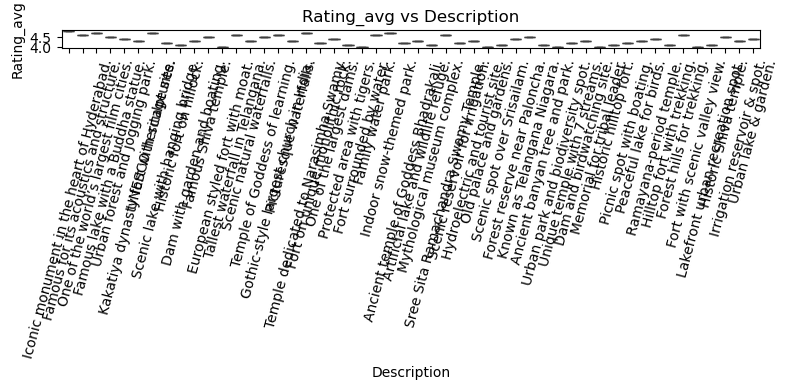

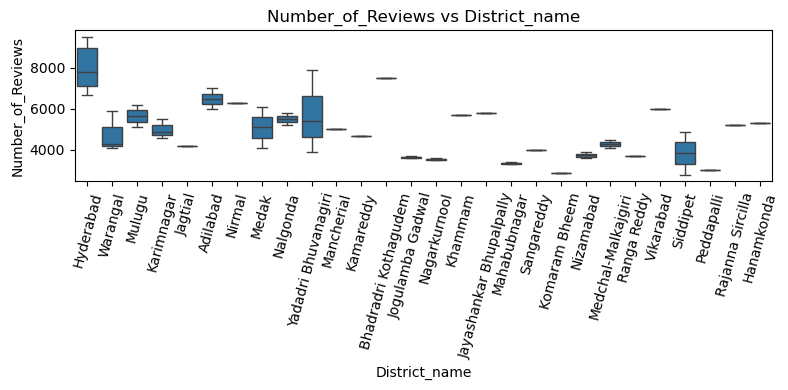

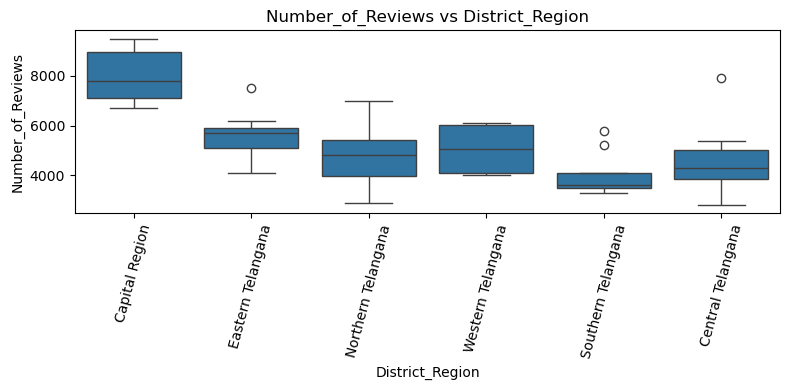

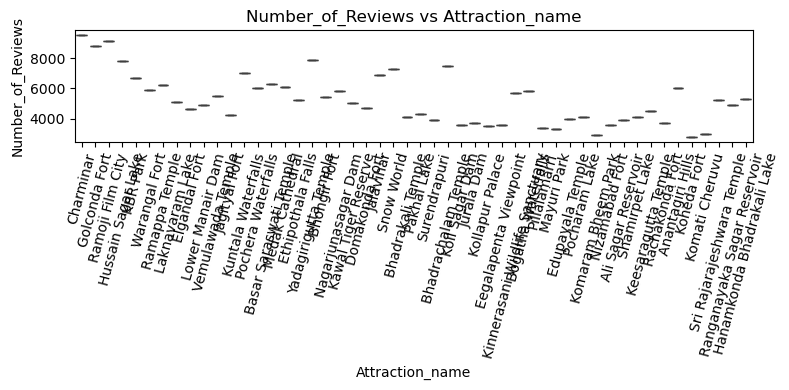

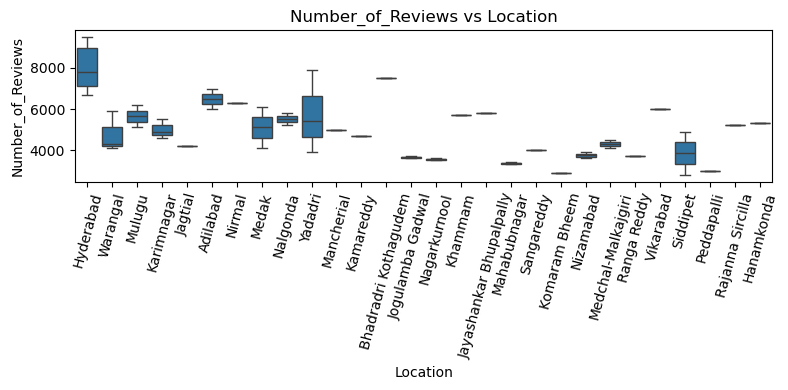

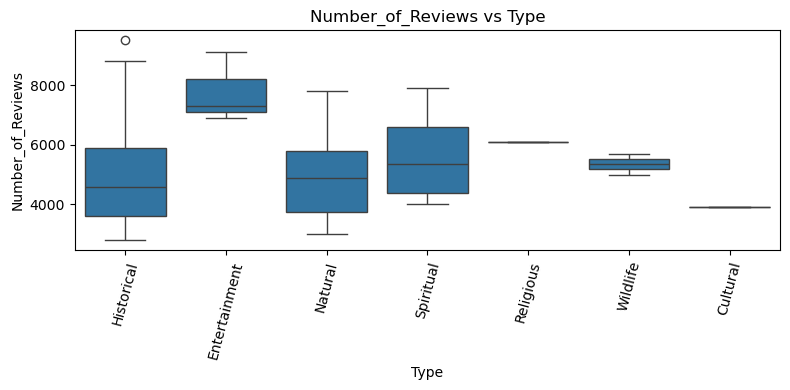

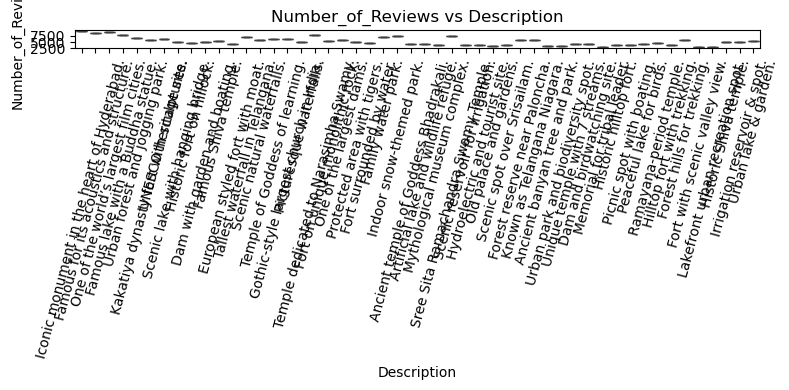

In [72]:
for num_col in numerical_cols:
    for cat_col in categorical_cols:
        plt.figure(figsize=(8, 4))
        sns.boxplot(x=cat_col, y=num_col, data=df)
        plt.title(f'{num_col} vs {cat_col}')
        plt.xticks(rotation=75)
        plt.tight_layout()
        plt.show()

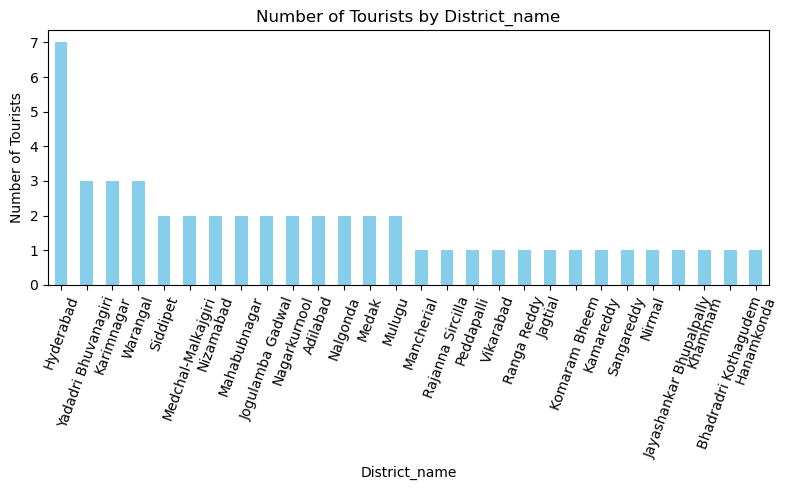

In [70]:
df['District_name'].value_counts().plot(kind='bar', color='skyblue', figsize=(8, 5))
plt.title('Number of Tourists by District_name')
plt.xlabel('District_name')
plt.ylabel('Number of Tourists')
plt.xticks(rotation=70)
plt.tight_layout()
plt.show()